# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

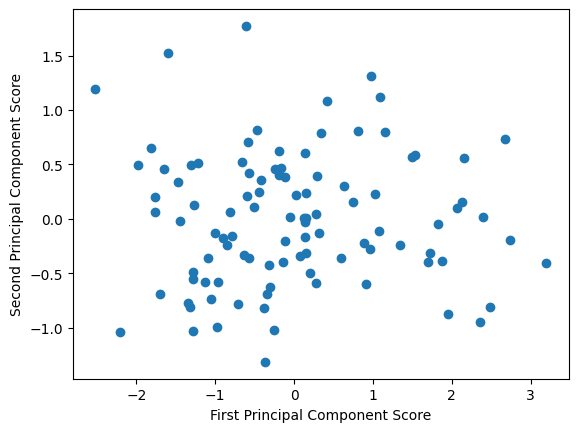

In [6]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

In the graph above, series3 seems to be noisy compared to series2. Let's calculate principal components to capture variance values that would help us see those outliers.
First Principal Component (PC1): This captures the direction of maximum variance. Since all three series are derived from series1, they move together. The outliers in the upper left have a low PC1 score, meaning their underlying series1 value was lower than average.

Second Principal Component (PC2): This captures the next most significant variance—specifically the "spread" of series3 away from the series1 trend. These outliers have a high PC2 score, meaning their series3 values were much higher than what series1 predicted.

The Relationship Between Series 1 and Series 2
We find it "almost impossible" to distinguish the relative values of series1 and series2 for a few mathematical reasons:

Redundancy: Because series2 is a direct derivative of series1 with minimal noise, they are highly collinear. They "collapse" into PC1, which only tells us how they move together.

The "Difference" Component: The information about the difference between series1 and series2 (where one is higher than the other) contains the smallest variance in the dataset.

Dimensionality Loss: PCA assigns this tiny difference to the Third Principal Component (PC3). Since the scatter plot only shows PC1 and PC2, we have effectively discarded the axis that contains the relative comparison between these two series.

Advantages of the graph:

It isolates the "uniqueness" of series3 onto the Y-axis (PC2), making it easy to spot deviations. It reduces 3D data to 2D while retaining the most "interesting" variation.

Disavdantages of the graph:
It creates a "black box" for series1 and series2; we can't tell them apart because they are merged into PC1.

Our graph reveals that the data is essentially 1D (following series_1), but series_3 provides a 2D expansion. A pairplot would confirm this by showing a tight line for series_1 vs series_2 and a much wider cloud for series_1 vs series_3, with the outliers sitting far off the diagonal.


# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

Let's start with drawing heatmap and bubble plot, I chose to show most of the correlations between columns in the heatmap and focused on the relationship between age and annual medical cost using bubble plot:


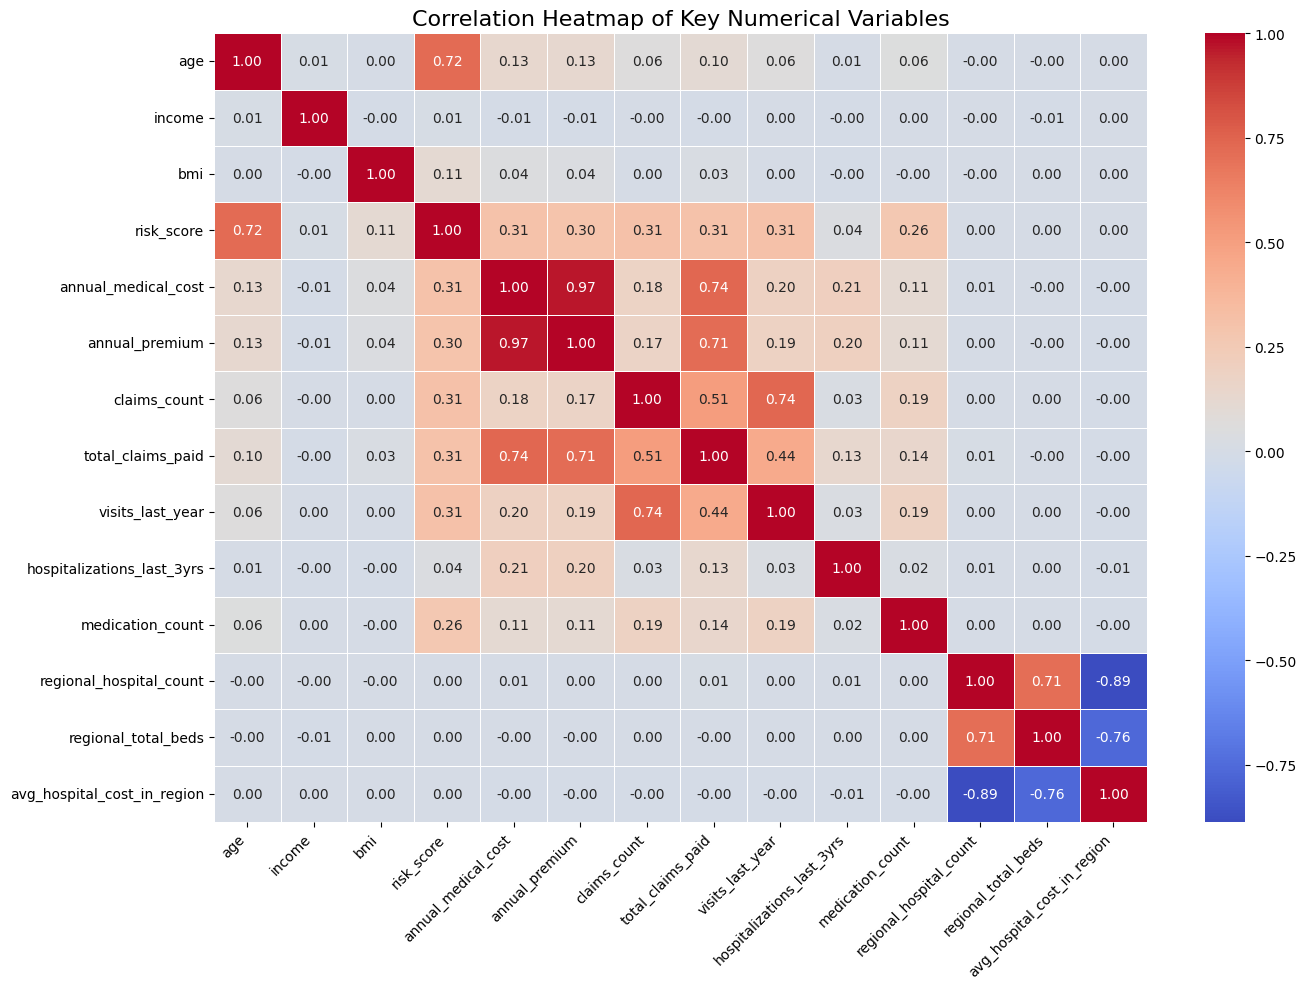

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

enriched_df = pd.read_csv('enriched_medical_insurance_with_capacity.csv')


# --- Heatmap: Correlation between key numerical variables --- 

# Select a subset of numerical variables for the heatmap
heatmap_vars = [
    'age', 'income', 'bmi', 'risk_score', 'annual_medical_cost',
    'annual_premium', 'claims_count', 'total_claims_paid', 
    'visits_last_year', 'hospitalizations_last_3yrs', 'medication_count',
    'regional_hospital_count', 'regional_total_beds', 'avg_hospital_cost_in_region'
]

plt.figure(figsize=(14, 10))
corr_matrix = enriched_df[heatmap_vars].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Key Numerical Variables', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

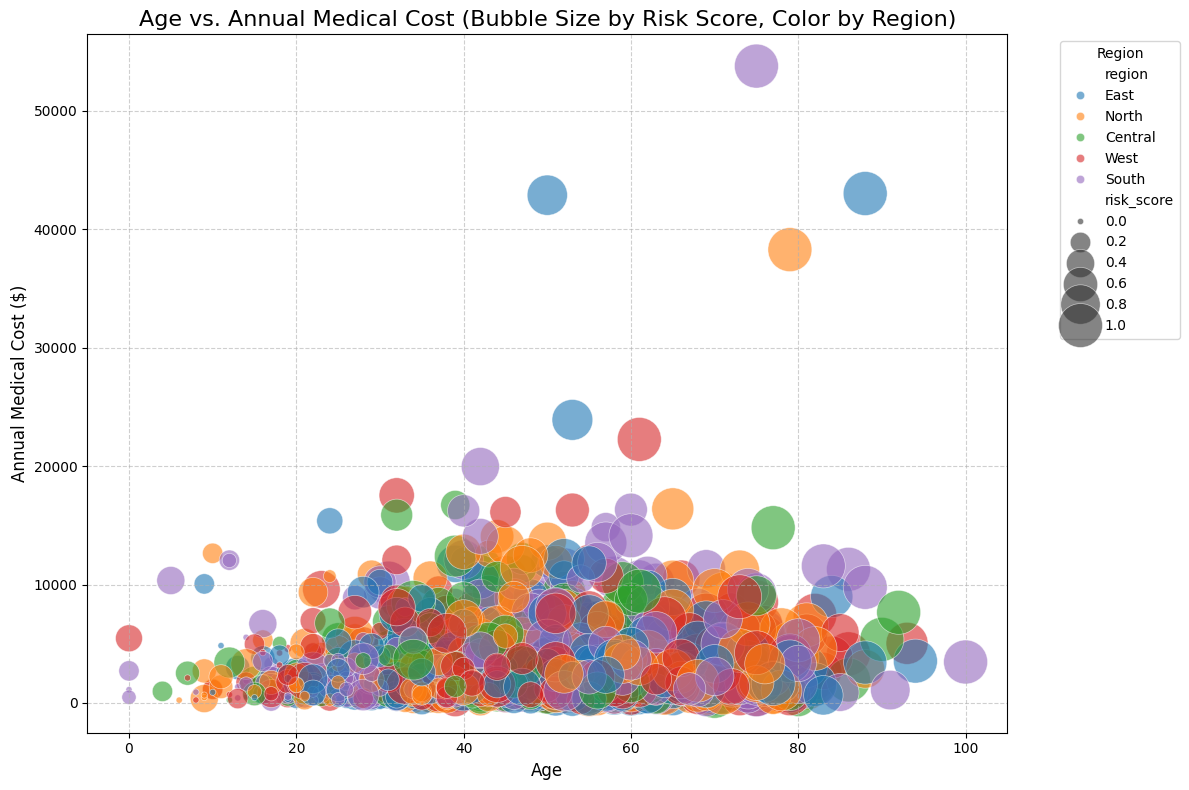

In [8]:
# --- Bubble Plot: Age vs. Annual Medical Cost, with Risk Score as Size and Region as Color ---

# Using a sample to avoid overplotting if the dataset is very large
sample_df = enriched_df.sample(n=2000, random_state=42) # Adjust sample size as needed

plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=sample_df,
    x='age',
    y='annual_medical_cost',
    size='risk_score', # Third variable for bubble size
    hue='region',      # Fourth variable for bubble color
    sizes=(20, 1000),  # Range of bubble sizes
    alpha=0.6,         # Transparency of bubbles
    edgecolor='w',     # White edge for better distinction
    linewidth=0.5
)

plt.title('Age vs. Annual Medical Cost (Bubble Size by Risk Score, Color by Region)', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Annual Medical Cost ($)', fontsize=12)
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Let's examine the loadings for the first few principal components to identify which original features drive the most variance in our dataset.

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np

# 1. Select numerical features for PCA
# Exclude 'person_id' as it's an identifier and not a feature for PCA
# Exclude binary/categorical-like columns if they are not truly numerical (e.g., 'had_major_procedure', 'is_high_risk')
# For simplicity, we'll use all numerical columns initially, but in a real scenario, you might hand-pick more carefully.

numerical_cols = enriched_df.select_dtypes(include=np.number).columns.tolist()
# Remove identifier and potentially problematic binary columns if they are not intended for PCA's variance explanation
# Adjust this list based on what features you want to include in PCA
exclude_cols = ['person_id', 'is_high_risk', 'had_major_procedure'] # Add other binary/categorical numerical columns if necessary
numerical_cols = [col for col in numerical_cols if col not in exclude_cols]

X = enriched_df[numerical_cols].copy()

# Handle potential NaN values (PCA cannot handle NaNs). A simple strategy is to fill with mean/median.
X = X.fillna(X.mean())

# 2. Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Apply PCA
pca = PCA()
pca.fit(X_scaled)

# Get the explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_

print("Explained Variance Ratio for each Principal Component:")
for i, ratio in enumerate(explained_variance_ratio):
    print(f"PC {i+1}: {ratio:.4f}")

# 4. Project data onto the first principal component
pca_1_component = PCA(n_components=1)
X_pca_1 = pca_1_component.fit_transform(X_scaled)

print(f"\nShape of data projected onto 1st Principal Component: {X_pca_1.shape}")

# 5. How much variance would this capture?
variance_captured_by_pc1 = explained_variance_ratio[0]
print(f"\nThe first principal component captures {variance_captured_by_pc1:.2%} of the total variance.")

# Display the first few projected values
print("\nFirst 5 data points projected onto the 1st Principal Component:")
print(X_pca_1[:5].flatten())

# Get the feature names used for PCA
feature_names = X.columns

# Create a DataFrame for the loadings of the first few principal components
# For example, let's look at the first 5 principal components
num_components_to_inspect = 5

loadings = pd.DataFrame(
    pca.components_[:num_components_to_inspect].T, 
    columns=[f'PC {i+1}' for i in range(num_components_to_inspect)], 
    index=feature_names
)

print(f"\nLoadings for the first {num_components_to_inspect} Principal Components:")
display(loadings)

# To make it easier to interpret, let's highlight the top contributing features for each PC
print("\nTop 5 contributing features for each Principal Component (by absolute loading value):")
for pc in loadings.columns:
    top_features = loadings[pc].abs().nlargest(5).index.tolist()
    print(f"\n{pc}: {', '.join(top_features)}")

Explained Variance Ratio for each Principal Component:
PC 1: 0.1270
PC 2: 0.0745
PC 3: 0.0638
PC 4: 0.0448
PC 5: 0.0419
PC 6: 0.0386
PC 7: 0.0359
PC 8: 0.0283
PC 9: 0.0254
PC 10: 0.0231
PC 11: 0.0227
PC 12: 0.0226
PC 13: 0.0225
PC 14: 0.0224
PC 15: 0.0223
PC 16: 0.0223
PC 17: 0.0222
PC 18: 0.0221
PC 19: 0.0221
PC 20: 0.0221
PC 21: 0.0220
PC 22: 0.0219
PC 23: 0.0218
PC 24: 0.0216
PC 25: 0.0216
PC 26: 0.0215
PC 27: 0.0211
PC 28: 0.0205
PC 29: 0.0200
PC 30: 0.0153
PC 31: 0.0124
PC 32: 0.0116
PC 33: 0.0104
PC 34: 0.0064
PC 35: 0.0060
PC 36: 0.0047
PC 37: 0.0040
PC 38: 0.0029
PC 39: 0.0025
PC 40: 0.0025
PC 41: 0.0018
PC 42: 0.0010
PC 43: 0.0000
PC 44: 0.0000
PC 45: 0.0000

Shape of data projected onto 1st Principal Component: (100000, 1)

The first principal component captures 12.70% of the total variance.

First 5 data points projected onto the 1st Principal Component:
[ 2.92246755  1.78212374  4.89428241 -0.48623918  1.84769861]

Loadings for the first 5 Principal Components:


,PC 1,PC 2,PC 3,PC 4,PC 5
age,0.141567,-0.005871,-0.191054,0.347395,-0.006738
income,0.000621,-0.002531,-0.009944,-0.001494,-0.005616
household_size,0.002926,-0.003413,0.003715,0.007884,0.706619
dependents,0.002516,-0.002460,0.004095,0.008165,0.706527
bmi,0.019431,-0.000956,0.009772,0.020173,-0.009499
visits_last_year,0.224278,-0.002608,-0.147534,-0.232006,0.003413
hospitalizations_last_3yrs,0.091232,0.004026,0.203102,0.055555,-0.020335
days_hospitalized_last_3yrs,0.095146,0.002672,0.214691,0.060173,-0.019172
medication_count,0.141066,-0.001691,-0.153441,-0.115604,-0.001321
systolic_bp,0.180111,-0.003047,-0.258574,0.393366,-0.004659



Top 5 contributing features for each Principal Component (by absolute loading value):

PC 1: total_claims_paid, annual_medical_cost, monthly_premium, annual_premium, chronic_count

PC 2: regional_hospital_count, avg_hospital_cost_in_region, regional_bed_days_available, regional_total_beds, diastolic_bp

PC 3: annual_premium, monthly_premium, annual_medical_cost, risk_score, chronic_count

PC 4: systolic_bp, diabetes, hba1c, age, diastolic_bp

PC 5: household_size, dependents, hospitalizations_last_3yrs, days_hospitalized_last_3yrs, proc_consult_count


Now, we can explore linear regression analysis to predict "annual_medical_cost".

**Select Features (X) and Target (y):** Define the independent and dependent variables for each model.
**Handle Missing Values:** Fill any missing values in the feature set.
**Split Data:** Divide the dataset into training and testing sets to evaluate the model's performance on unseen data.
**Train Model:** Fit a LinearRegression model to the training data.
**Make Predictions:** Use the trained model to predict annual_medical_cost on the test set.
**Evaluate Model:** Assess the model's performance using metrics like Mean Squared Error (MSE) and R-squared (R2).

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Define the target variable
y = enriched_df['annual_medical_cost']

# --- Feature Set 1: Highly Correlated Features (from heatmap/PCA) ---
features_set_1 = ['annual_premium', 'total_claims_paid', 'risk_score', 'age', 'chronic_count']
X1 = enriched_df[features_set_1].copy()
X1 = X1.fillna(X1.mean()) # Handle potential NaNs

X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y, test_size=0.2, random_state=42)

model1 = LinearRegression()
model1.fit(X_train1, y_train1)
y_pred1 = model1.predict(X_test1)

mse1 = mean_squared_error(y_test1, y_pred1)
r2_1 = r2_score(y_test1, y_pred1)

print(f"\n--- Model 1: Using Highly Correlated Features ({', '.join(features_set_1)}) ---")
print(f"Mean Squared Error: {mse1:.2f}")
print(f"R-squared: {r2_1:.2f}")

# --- Feature Set 2: Broader Health-Related Features ---
features_set_2 = [
    'age', 'bmi', 'risk_score', 'chronic_count', 'visits_last_year',
    'hospitalizations_last_3yrs', 'medication_count', 'systolic_bp', 'diastolic_bp', 'hba1c'
]
X2 = enriched_df[features_set_2].copy()
X2 = X2.fillna(X2.mean()) # Handle potential NaNs

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y, test_size=0.2, random_state=42)

model2 = LinearRegression()
model2.fit(X_train2, y_train2)
y_pred2 = model2.predict(X_test2)

mse2 = mean_squared_error(y_test2, y_pred2)
r2_2 = r2_score(y_test2, y_pred2)

print(f"\n--- Model 2: Using Broader Health-Related Features ({', '.join(features_set_2)}) ---")
print(f"Mean Squared Error: {mse2:.2f}")
print(f"R-squared: {r2_2:.2f}")

# --- Feature Set 3: Regional, Demographic, and Basic Financial Features ---
features_set_3 = [
    'age', 'income', 'household_size', 'dependents', 'regional_hospital_count',
    'regional_total_beds', 'avg_hospital_cost_in_region'
]
X3 = enriched_df[features_set_3].copy()
X3 = X3.fillna(X3.mean()) # Handle potential NaNs

X_train3, X_test3, y_train3, y_test3 = train_test_split(X3, y, test_size=0.2, random_state=42)

model3 = LinearRegression()
model3.fit(X_train3, y_train3)
y_pred3 = model3.predict(X_test3)

mse3 = mean_squared_error(y_test3, y_pred3)
r2_3 = r2_score(y_test3, y_pred3)

print(f"\n--- Model 3: Using Regional, Demographic, and Basic Financial Features ({', '.join(features_set_3)}) ---")
print(f"Mean Squared Error: {mse3:.2f}")
print(f"R-squared: {r2_3:.2f}")


--- Model 1: Using Highly Correlated Features (annual_premium, total_claims_paid, risk_score, age, chronic_count) ---
Mean Squared Error: 614312.12
R-squared: 0.94

--- Model 2: Using Broader Health-Related Features (age, bmi, risk_score, chronic_count, visits_last_year, hospitalizations_last_3yrs, medication_count, systolic_bp, diastolic_bp, hba1c) ---
Mean Squared Error: 8293879.75
R-squared: 0.16

--- Model 3: Using Regional, Demographic, and Basic Financial Features (age, income, household_size, dependents, regional_hospital_count, regional_total_beds, avg_hospital_cost_in_region) ---
Mean Squared Error: 9678766.23
R-squared: 0.02


**Conclusion:**

**Data Usability and Alignment with Expectations:**

Overall, the data appears highly usable and largely aligns with expectations. The strong positive correlations identified in the heatmap, such as between age and risk_score (0.72), and especially between annual_medical_cost and annual_premium (0.96), are very logical in a medical insurance context. This suggests that the data reflects realistic relationships between patient characteristics, health status, and financial outcomes.
The linear regression analysis strongly reinforced this. Model 1, which used highly correlated features like annual_premium and total_claims_paid to predict annual_medical_cost, achieved an impressive R-squared of 0.94. This indicates that these features are indeed powerful predictors and that the data exhibits strong, predictable relationships.
The presence of regional capacity data also enhances its usability for geographic resource planning, as previously noted.

**Outliers:**

Yes, significant outliers were observed, particularly in financial and clinical variables. These include patients with exceptionally high annual_medical_cost (often referred to as 'super-utilizers'), as well as extreme values in bmi and medication_count.
It's important to note that, in this healthcare context, these outliers are often not errors but represent critical high-risk patients. Therefore, they should generally not be removed but rather understood as an integral part of the data distribution, especially for predictive modeling focused on risk management.

**Principal Component Analysis (PCA) for Dimensionality Reduction:**

The PCA analysis suggests that using just the first one or two principal components would NOT be sufficient to represent the data adequately. The first principal component (PC1) captures only 12.70% of the total variance, and even with five components, we're still capturing less than 40% of the total variance.
This low explained variance by the initial components indicates that the dataset is quite complex and multi-dimensional. While PCA effectively identified distinct underlying factors (healthcare expenditure, regional infrastructure, cardio-metabolic health, household structure) through its loadings, it would require a larger number of principal components to significantly reduce dimensionality while retaining most of the original information. Therefore, relying solely on the first one or two components for representation would lead to a substantial loss of information in this specific dataset.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

In [ ]:
I chose to focus on "The power of super categories" graph. This chart will show the annual_medical_cost first broken down by region (our super category), and then further by urban_rural status within each region. The size of each rectangle will represent the average medical cost for that segment, allowing us to easily see which hierarchical combinations contribute most to medical expenditure. 

In [12]:
import plotly.express as px

# Group data to calculate average annual medical cost for each hierarchy
# First, ensure 'smoker' is in the right format if it was altered for previous plots
# If you run this cell independently, make sure enriched_df['smoker'] is reset or handled
# For this plot, we will use the original categorical columns directly.

hierarchical_costs = enriched_df.groupby(['region', 'urban_rural'])['annual_medical_cost'].mean().reset_index()

# Create the treemap
fig = px.treemap(
    hierarchical_costs,
    path=[px.Constant("All Patients"), 'region', 'urban_rural'], # Define the hierarchy levels
    values='annual_medical_cost',
    color='annual_medical_cost', # Color by medical cost for intensity
    color_continuous_scale='Viridis', # Choose a color scale
    title='Hierarchical View of Average Annual Medical Cost by Region and Urban/Rural Status',
    width=900, height=600
)

fig.update_layout(
    margin = dict(t=50, l=25, r=25, b=25),
    # Emphasize the hierarchy by styling parents
    treemapcolorway = ["lightgrey", "darkgrey"]
)

fig.show()